In [310]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")  # sube de /notebooks a la raíz del proyecto

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos


In [311]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos


In [3]:
import os
import sys

PROJECT_ROOT = r"C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos"

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print("Ruta agregada:", PROJECT_ROOT)
print("scripts existe?:", os.path.exists(os.path.join(PROJECT_ROOT, "scripts")))

Ruta agregada: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos
scripts existe?: True


In [4]:
from scripts.database import test_connection
print("Importación correcta")
print(test_connection())

Importación correcta
True


In [2]:
import os
import sys
from dotenv import load_dotenv

PROJECT_ROOT = os.path.abspath("..")
ENV_PATH = os.path.join(PROJECT_ROOT, ".env")

print("PROJECT_ROOT:", PROJECT_ROOT)
print("ENV_PATH:", ENV_PATH)
print("¿Existe .env?:", os.path.exists(ENV_PATH))

load_dotenv(ENV_PATH, override=True)

print("DB_HOST:", os.getenv("DB_HOST"))
print("DB_PORT:", os.getenv("DB_PORT"))
print("DB_USER:", os.getenv("DB_USER"))
print("DB_NAME:", os.getenv("DB_NAME"))

pwd = os.getenv("DB_PASSWORD")
print("¿Password cargada?:", pwd is not None)
print("Longitud password:", len(pwd) if pwd else 0)

PROJECT_ROOT: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos
ENV_PATH: C:\Users\LENOVO\Grupo7-_Motta_Rivera\Proyecto_catalogo_videojuegos\.env
¿Existe .env?: True
DB_HOST: localhost
DB_PORT: 5432
DB_USER: postgres
DB_NAME: catalogo_videojuegos
¿Password cargada?: True
Longitud password: 11


In [13]:
import pandas as pd

df_csv = pd.read_csv("../data/igdb.csv")
print(df_csv.shape)
df_csv.head()

(99, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [14]:
print(df_csv.columns.tolist())

['query', 'id', 'nombre', 'fecha_lanzamiento', 'rating', 'rating_count', 'generos', 'plataformas', 'cover_url', 'fecha_extraccion']


In [15]:
from scripts.database import engine

df_csv.to_sql("juegos_csv", engine, if_exists="replace", index=False)
print("Tabla juegos_csv cargada en PostgreSQL")

Tabla juegos_csv cargada en PostgreSQL


In [16]:
query = "SELECT * FROM juegos_csv LIMIT 10"
df_real = pd.read_sql(query, engine)
print(df_real.shape)
df_real.head()

(10, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [17]:
query = "SELECT * FROM juegos_csv"
df_real = pd.read_sql(query, engine)

print("Dimensiones:", df_real.shape)
df_real.head()

Dimensiones: (99, 10)


,query,id,nombre,fecha_lanzamiento,rating,rating_count,generos,plataformas,cover_url,fecha_extraccion
0,zelda,1022,The Legend of Zelda,509328000.0,80.335612,705.0,Adventure,"Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363358
1,zelda,1025,Zelda II: The Adventure of Link,537580800.0,65.971192,289.0,"Platform, Role-playing (RPG), Adventure","Family Computer Disk System, Nintendo 3DS, Wii...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363408
2,zelda,1041,The Legend of Zelda: Oracle of Ages,983232000.0,84.269177,164.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363427
3,zelda,1032,The Legend of Zelda: Oracle of Seasons,983232000.0,81.302509,189.0,"Puzzle, Role-playing (RPG), Adventure","Game Boy Color, Nintendo 3DS",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363442
4,zelda,1026,The Legend of Zelda: A Link to the Past,690681600.0,92.332359,1632.0,"Puzzle, Adventure","Satellaview, Super Nintendo Entertainment Syst...",//images.igdb.com/igdb/image/upload/t_thumb/co...,2026-02-19T08:21:22.363458


In [18]:
df_model = df_real.copy()

# Convertir fecha_lanzamiento desde epoch/Unix seconds
df_model["fecha_lanzamiento"] = pd.to_datetime(
    df_model["fecha_lanzamiento"],
    unit="s",
    errors="coerce"
)

# Año de lanzamiento
df_model["release_year"] = df_model["fecha_lanzamiento"].dt.year

# Cantidad de géneros
df_model["genre_count"] = (
    df_model["generos"]
    .fillna("")
    .apply(lambda x: len([g for g in str(x).split(",") if g.strip()]))
)

# Cantidad de plataformas
df_model["platform_count"] = (
    df_model["plataformas"]
    .fillna("")
    .apply(lambda x: len([p for p in str(x).split(",") if p.strip()]))
)

# Longitud del nombre del juego
df_model["title_length"] = df_model["nombre"].fillna("").str.len()

print("Dimensiones antes de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones antes de limpiar: (99, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [19]:
df_model = df_model.dropna(subset=["rating", "rating_count", "release_year"]).copy()

print("Dimensiones después de limpiar:", df_model.shape)
df_model[[
    "nombre", "rating", "rating_count",
    "release_year", "genre_count",
    "platform_count", "title_length"
]].head()

Dimensiones después de limpiar: (42, 14)


,nombre,rating,rating_count,release_year,genre_count,platform_count,title_length
0,The Legend of Zelda,80.335612,705.0,1986.0,1,6,19
1,Zelda II: The Adventure of Link,65.971192,289.0,1987.0,3,5,31
2,The Legend of Zelda: Oracle of Ages,84.269177,164.0,2001.0,3,2,35
3,The Legend of Zelda: Oracle of Seasons,81.302509,189.0,2001.0,3,2,38
4,The Legend of Zelda: A Link to the Past,92.332359,1632.0,1991.0,2,6,39


In [20]:
features_real = [
    "release_year",
    "rating_count",
    "genre_count",
    "platform_count",
    "title_length"
]

X_real_reg = df_model[features_real]
y_real_reg = df_model["rating"]

print("X_real_reg:", X_real_reg.shape)
print("y_real_reg:", y_real_reg.shape)
print(X_real_reg.head())

X_real_reg: (42, 5)
y_real_reg: (42,)
   release_year  rating_count  genre_count  platform_count  title_length
0        1986.0         705.0            1               6            19
1        1987.0         289.0            3               5            31
2        2001.0         164.0            3               2            35
3        2001.0         189.0            3               2            38
4        1991.0        1632.0            2               6            39


In [21]:
umbral = 65
df_model["rating_bin"] = (df_model["rating"] >= umbral).astype(int)

print("Conteo por clase:")
print(df_model["rating_bin"].value_counts().sort_index())

print("\nProporción por clase:")
print(df_model["rating_bin"].value_counts(normalize=True).sort_index().round(4))

Conteo por clase:
rating_bin
0     8
1    34
Name: count, dtype: int64

Proporción por clase:
rating_bin
0    0.1905
1    0.8095
Name: proportion, dtype: float64


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import numpy as np

In [27]:
X_real_bin = df_model[features_real]
y_real_bin = df_model["rating_bin"]

print("X_real_bin:", X_real_bin.shape)
print("y_real_bin:", y_real_bin.shape)
print(y_real_bin.value_counts().sort_index())

X_real_bin: (42, 5)
y_real_bin: (42,)
rating_bin
0     8
1    34
Name: count, dtype: int64


In [28]:
X_train_real_bin, X_test_real_bin, y_train_real_bin, y_test_real_bin = train_test_split(
    X_real_bin, y_real_bin, test_size=0.2, random_state=42, stratify=y_real_bin
)

print("Entrenamiento X:", X_train_real_bin.shape)
print("Prueba X:", X_test_real_bin.shape)
print("Distribución entrenamiento:")
print(y_train_real_bin.value_counts().sort_index())
print("Distribución prueba:")
print(y_test_real_bin.value_counts().sort_index())

Entrenamiento X: (33, 5)
Prueba X: (9, 5)
Distribución entrenamiento:
rating_bin
0     6
1    27
Name: count, dtype: int64
Distribución prueba:
rating_bin
0    2
1    7
Name: count, dtype: int64


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

log_real = LogisticRegression(max_iter=1000, random_state=42)
log_real.fit(X_train_real_bin, y_train_real_bin)

y_pred_log_real = log_real.predict(X_test_real_bin)
y_prob_log_real = log_real.predict_proba(X_test_real_bin)[:, 1]

acc_log_real = accuracy_score(y_test_real_bin, y_pred_log_real)
prec_log_real = precision_score(y_test_real_bin, y_pred_log_real, zero_division=0)
rec_log_real = recall_score(y_test_real_bin, y_pred_log_real, zero_division=0)
f1_log_real = f1_score(y_test_real_bin, y_pred_log_real, zero_division=0)

print("REGRESIÓN LOGÍSTICA BINARIA - DATOS REALES")
print("Accuracy:", round(acc_log_real, 4))
print("Precision:", round(prec_log_real, 4))
print("Recall:", round(rec_log_real, 4))
print("F1-score:", round(f1_log_real, 4))

REGRESIÓN LOGÍSTICA BINARIA - DATOS REALES
Accuracy: 0.8889
Precision: 0.875
Recall: 1.0
F1-score: 0.9333


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

[[1 1]
 [0 7]]


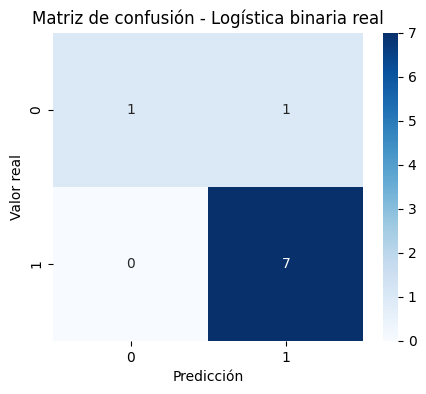

In [32]:
cm_log_real = confusion_matrix(y_test_real_bin, y_pred_log_real)
print(cm_log_real)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log_real, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Logística binaria real")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [298]:
import sys
!{sys.executable} -m pip install python-dotenv sqlalchemy psycopg2-binary

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---- ----------------------------------- 0.3/2.1 MB ? eta -:--:--
   -------------- ------------------------- 0.8/2.1 MB 4.7 MB/s eta 0:00:01
   ---------------------------------------  2.1/2.1 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 4.0 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   -------------- ------------------------- 1.0/2.8 MB 10.4 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.8 MB 6.6 MB/s eta 0:00:01
   ------------------------------------ --- 2.6/2.8 MB 6.5 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 4.9 MB/s  0:00:00

   ---------------------------------------- 0/4 [python-dotenv]
   ---------- ----------------------------- 1/4 [psycopg2-binary]
   ---------- ----------------------------- 1/4 [psycopg2-binary]
   ---------- ----------------------------- 1/4 [psycopg2-binary]
   


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [242]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import shapiro, probplot
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

np.random.seed(42)
n = 1000

# Variables con distintas distribuciones
release_year = np.random.randint(2015, 2026, n)                    # discreta
metascore = np.clip(np.random.normal(76, 9, n), 45, 98)           # normal
price_usd = np.clip(np.random.normal(45, 12, n), 10, 80)          # normal
hours_gameplay = np.clip(np.random.gamma(4, 10, n), 5, 120)       # gamma
marketing_score = np.clip(np.random.lognormal(2.0, 0.6, n), 2, 120)  # lognormal
social_hype = np.random.beta(2, 5, n) * 100                       # beta
discount_pct = np.random.uniform(0, 60, n)                        # uniforme
bugs_reported = np.random.poisson(6, n)                           # poisson

# rating_count depende de marketing y hype
rating_count = (
    marketing_score * 95
    + social_hype * 25
    + np.random.normal(0, 180, n)
)
rating_count = np.clip(rating_count, 50, None).round()

# rating depende de varias variables
rating = (
    8
    + 0.65 * metascore
    + 0.05 * hours_gameplay
    + 0.035 * social_hype
    + 0.0032 * rating_count
    - 0.95 * bugs_reported
    - 0.08 * price_usd
    + 0.06 * discount_pct
    + np.random.normal(0, 2.2, n)
)

rating = np.clip(rating, 50, 99)

df = pd.DataFrame({
    "release_year": release_year,
    "metascore": metascore.round(2),
    "price_usd": price_usd.round(2),
    "hours_gameplay": hours_gameplay.round(2),
    "marketing_score": marketing_score.round(2),
    "social_hype": social_hype.round(2),
    "discount_pct": discount_pct.round(2),
    "bugs_reported": bugs_reported,
    "rating_count": rating_count.astype(int),
    "rating": rating.round(2)
})

df.head()

,release_year,metascore,price_usd,hours_gameplay,marketing_score,social_hype,discount_pct,bugs_reported,rating_count,rating
0,2021,57.66,45.80,20.71,25.16,16.06,59.39,10,2921,50.00
1,2018,66.93,51.19,50.60,12.59,21.77,24.41,6,1667,51.68
2,2025,59.16,26.25,37.40,9.18,14.66,0.66,6,1090,50.00
3,2022,72.84,38.65,15.34,9.54,9.44,10.19,3,1079,53.04
4,2019,76.17,54.53,113.23,14.37,63.59,39.15,9,2816,64.44


In [243]:
df.to_csv("../data/videojuegos_sinteticos.csv", index=False)
print("CSV guardado en ../data/videojuegos_sinteticos.csv")

CSV guardado en ../data/videojuegos_sinteticos.csv


In [258]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree


In [261]:
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

In [266]:
umbral = 65

df["rating_bin"] = (df["rating"] >= umbral).astype(int)

print("Variable binaria creada correctamente")
print("\nDefinición:")
print("1 = rating alto (>= 65)")
print("0 = rating menor a 65")

print("\nConteo por clase:")
print(df["rating_bin"].value_counts().sort_index())

Variable binaria creada correctamente

Definición:
1 = rating alto (>= 65)
0 = rating menor a 65

Conteo por clase:
rating_bin
0    814
1    186
Name: count, dtype: int64


In [267]:
print("Proporción por clase:")
print(df["rating_bin"].value_counts(normalize=True).sort_index().round(4))

Proporción por clase:
rating_bin
0    0.814
1    0.186
Name: proportion, dtype: float64


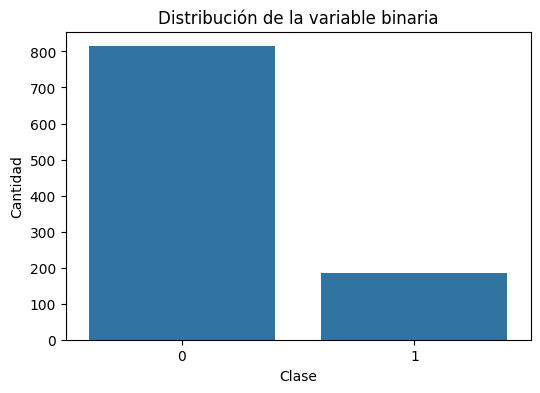

In [268]:
plt.figure(figsize=(6,4))
sns.countplot(x="rating_bin", data=df)
plt.title("Distribución de la variable binaria")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()

In [269]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [270]:
X_bin = df[[
    "metascore",
    "price_usd",
    "hours_gameplay",
    "social_hype",
    "discount_pct",
    "bugs_reported",
    "rating_count"
]]

y_bin = df["rating_bin"]

print("Variables independientes:")
print(X_bin.columns.tolist())
print("\nVariable dependiente:")
print("rating_bin")
print("\nForma de X:", X_bin.shape)
print("Forma de y:", y_bin.shape)

Variables independientes:
['metascore', 'price_usd', 'hours_gameplay', 'social_hype', 'discount_pct', 'bugs_reported', 'rating_count']

Variable dependiente:
rating_bin

Forma de X: (1000, 7)
Forma de y: (1000,)


In [272]:
log_model = LogisticRegression(max_iter=1000, random_state=42)

log_model.fit(X_train_b, y_train_b)

print("Regresión logística binaria entrenada correctamente")

Regresión logística binaria entrenada correctamente


In [273]:
y_pred_log = log_model.predict(X_test_b)
y_prob_log = log_model.predict_proba(X_test_b)[:, 1]

print("Primeras 10 probabilidades de clase 1:")
print(y_prob_log[:10])

print("\nPrimeras 10 clases predichas:")
print(y_pred_log[:10])

Primeras 10 probabilidades de clase 1:
[5.86778599e-02 9.86055071e-08 1.41531750e-02 6.99079810e-03
 3.50101904e-03 2.17840119e-03 1.46779668e-01 3.95891696e-02
 3.11827733e-04 2.16267608e-03]

Primeras 10 clases predichas:
[0 0 0 0 0 0 0 0 0 0]


In [274]:
acc_log = accuracy_score(y_test_b, y_pred_log)
prec_log = precision_score(y_test_b, y_pred_log, zero_division=0)
rec_log = recall_score(y_test_b, y_pred_log, zero_division=0)
f1_log = f1_score(y_test_b, y_pred_log, zero_division=0)

print("REGRESIÓN LOGÍSTICA BINARIA - MODELO BASE")
print("Accuracy:", round(acc_log, 4))
print("Precision:", round(prec_log, 4))
print("Recall:", round(rec_log, 4))
print("F1-score:", round(f1_log, 4))

REGRESIÓN LOGÍSTICA BINARIA - MODELO BASE
Accuracy: 0.945
Precision: 0.8824
Recall: 0.8108
F1-score: 0.8451


In [275]:
cm_log = confusion_matrix(y_test_b, y_pred_log)
print("Matriz de confusión:")
print(cm_log)

Matriz de confusión:
[[159   4]
 [  7  30]]


In [276]:
print("Reporte de clasificación:")
print(classification_report(y_test_b, y_pred_log, digits=4, zero_division=0))

Reporte de clasificación:
              precision    recall  f1-score   support

           0     0.9578    0.9755    0.9666       163
           1     0.8824    0.8108    0.8451        37

    accuracy                         0.9450       200
   macro avg     0.9201    0.8931    0.9058       200
weighted avg     0.9439    0.9450    0.9441       200



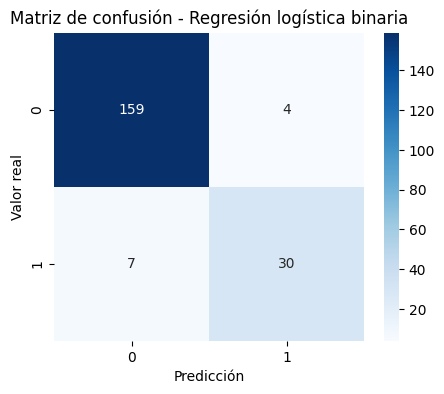

In [277]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión - Regresión logística binaria")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.show()

In [293]:
comparacion_binaria = pd.DataFrame({
    "Modelo": [
        "Logística base",
        "Árbol binario base",
        "Logística + Oversampling",
        "Árbol + Oversampling"
    ],
    "Accuracy": [
        acc_log,
        acc_tree_bin,
        acc_log_over,
        acc_tree_over
    ],
    "Precision": [
        prec_log,
        prec_tree_bin,
        prec_log_over,
        prec_tree_over
    ],
    "Recall": [
        rec_log,
        rec_tree_bin,
        rec_log_over,
        rec_tree_over
    ],
    "F1": [
        f1_log,
        f1_tree_bin,
        f1_log_over,
        f1_tree_over
    ]
})

comparacion_binaria.round(4)

,Modelo,Accuracy,Precision,Recall,F1
0,Logística base,0.945,0.8824,0.8108,0.8451
1,Árbol binario base,0.890,0.7778,0.5676,0.6562
2,Logística + Oversampling,0.945,0.7826,0.9730,0.8675
3,Árbol + Oversampling,0.900,0.6667,0.9189,0.7727
